# Week 2 Day 5 — Explainable Patient-Level Prediction

## ICU Early Warning Prediction System

In Week 2 Day 4, a single-patient prediction pipeline was created.

The system could predict:

- sepsis probability
- risk score
- risk category
- clinical alert message

Today, the objective is to make each patient-level prediction explainable.

This notebook combines:

- saved model loading
- single-patient prediction
- SHAP explanation
- patient-level clinical interpretation

This is important because in healthcare AI, a prediction alone is not enough. Clinicians also need to understand which physiological features influenced the prediction.

In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures" / "day12"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Models path:", MODELS_DIR)
print("Results path:", RESULTS_DIR)
print("Figures path:", FIGURES_DIR)
print("Figure directory exists:", FIGURES_DIR.exists())

Project root: c:\Users\User\OneDrive\Desktop\icu-early-warning-system
Data path: c:\Users\User\OneDrive\Desktop\icu-early-warning-system\data\processed
Models path: c:\Users\User\OneDrive\Desktop\icu-early-warning-system\models
Results path: c:\Users\User\OneDrive\Desktop\icu-early-warning-system\results
Figures path: c:\Users\User\OneDrive\Desktop\icu-early-warning-system\figures\day12
Figure directory exists: True


In [4]:
model_path = MODELS_DIR / "gradient_boosting_smote_model.joblib"
feature_names_path = MODELS_DIR / "model_feature_names.joblib"
metadata_path = MODELS_DIR / "model_metadata.joblib"

model = joblib.load(model_path)
feature_names = joblib.load(feature_names_path)
metadata = joblib.load(metadata_path)

print("Saved model loaded successfully.")
print("Model name:", metadata["model_name"])
print("Number of features:", len(feature_names))

Saved model loaded successfully.
Model name: Gradient Boosting + SMOTE
Number of features: 16


In [5]:
data_file = DATA_PATH / "day2_patient_level_features.csv"

df = pd.read_csv(data_file)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (100, 18)


,Patient_ID,HR_mean,HR_max,HR_min,O2Sat_mean,O2Sat_min,Temp_mean,Temp_max,SBP_mean,SBP_min,MAP_mean,MAP_min,Resp_mean,Resp_max,Age_first,Gender_first,ICULOS_max,SepsisLabel_max
0,p000001,101.907407,117.0,76.0,91.453704,85.0,36.735185,37.44,127.870370,78.0,88.321111,44.00,24.555556,32.0,83.14,0,54,0
1,p000002,62.173913,94.0,54.0,97.043478,94.0,36.206087,37.00,129.043478,114.0,67.239130,50.50,14.630435,27.0,75.91,0,23,0
2,p000003,79.968750,93.0,68.0,95.375000,91.0,37.465000,38.61,139.760417,121.0,81.149167,62.67,25.302083,40.0,45.82,0,48,0
3,p000004,102.172414,113.0,89.0,98.189655,95.5,36.463103,37.00,113.017241,90.0,67.063103,34.00,18.758621,26.0,65.71,0,29,0
4,p000005,76.604167,88.0,61.0,97.677083,96.0,37.072292,37.33,135.072917,114.0,90.364583,73.00,15.447917,21.0,28.09,1,49,0


In [6]:
target_col = "SepsisLabel_max"

X = df[feature_names]
y = df[target_col]
patient_ids = df["Patient_ID"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (100, 16)
Target shape: (100,)


In [7]:
def categorize_risk(probability):
    risk_score = probability * 100

    if risk_score < 25:
        return "Low Risk"
    elif risk_score < 50:
        return "Moderate Risk"
    elif risk_score < 75:
        return "High Risk"
    else:
        return "Critical Risk"

In [8]:
def generate_clinical_alert(risk_category):
    if risk_category == "Low Risk":
        return "Routine monitoring recommended."
    elif risk_category == "Moderate Risk":
        return "Increase monitoring frequency and reassess patient condition."
    elif risk_category == "High Risk":
        return "Clinical review recommended due to elevated sepsis risk."
    else:
        return "Urgent clinical review recommended due to critical sepsis risk."

In [9]:
explainer = shap.Explainer(model, X)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [10]:
patient_index = 0

patient_row = X.iloc[[patient_index]]
patient_id = patient_ids.iloc[patient_index]
true_label = y.iloc[patient_index]

probability = model.predict_proba(patient_row)[0, 1]
prediction = model.predict(patient_row)[0]

risk_score = probability * 100
risk_category = categorize_risk(probability)
clinical_alert = generate_clinical_alert(risk_category)

print("Patient ID:", patient_id)
print("True sepsis label:", true_label)
print("Predicted sepsis label:", prediction)
print("Sepsis probability:", round(probability, 3))
print("Risk score:", round(risk_score, 2), "%")
print("Risk category:", risk_category)
print("Clinical alert:", clinical_alert)

Patient ID: p000001
True sepsis label: 0
Predicted sepsis label: 0
Sepsis probability: 0.001
Risk score: 0.12 %
Risk category: Low Risk
Clinical alert: Routine monitoring recommended.


In [11]:
patient_shap_values = explainer(patient_row)

print("Patient SHAP values generated successfully.")
print("SHAP values shape:", patient_shap_values.values.shape)

Patient SHAP values generated successfully.
SHAP values shape: (1, 16)


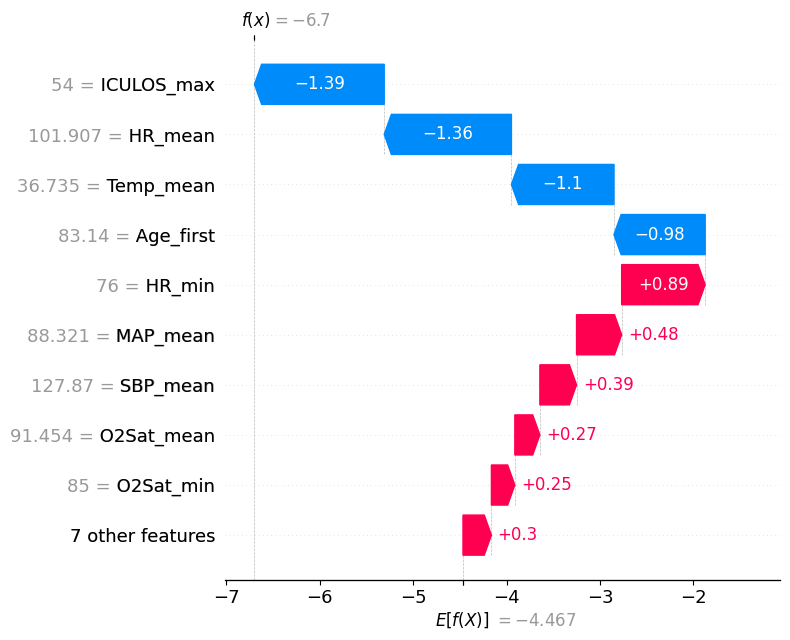

In [12]:
shap.plots.waterfall(
    patient_shap_values[0],
    show=False
)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "day12_single_patient_shap_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
patient_explanation = pd.DataFrame({
    "Feature": feature_names,
    "Feature_Value": patient_row.iloc[0].values,
    "SHAP_Value": patient_shap_values.values[0]
})

patient_explanation["Absolute_SHAP_Value"] = patient_explanation["SHAP_Value"].abs()

patient_explanation = patient_explanation.sort_values(
    by="Absolute_SHAP_Value",
    ascending=False
)

patient_explanation.head(10)

,Feature,Feature_Value,SHAP_Value,Absolute_SHAP_Value
15,ICULOS_max,54.000000,-1.389178,1.389178
0,HR_mean,101.907407,-1.361929,1.361929
5,Temp_mean,36.735185,-1.097942,1.097942
13,Age_first,83.140000,-0.976525,0.976525
2,HR_min,76.000000,0.894232,0.894232
9,MAP_mean,88.321111,0.482968,0.482968
7,SBP_mean,127.870370,0.392639,0.392639
3,O2Sat_mean,91.453704,0.268284,0.268284
4,O2Sat_min,85.000000,0.250587,0.250587
10,MAP_min,44.000000,0.142187,0.142187


In [14]:
top_risk_drivers = patient_explanation[
    patient_explanation["SHAP_Value"] > 0
].head(5)

top_protective_factors = patient_explanation[
    patient_explanation["SHAP_Value"] < 0
].head(5)

print("Top features increasing predicted sepsis risk:")
display(top_risk_drivers)

print("Top features decreasing predicted sepsis risk:")
display(top_protective_factors)

Top features increasing predicted sepsis risk:


,Feature,Feature_Value,SHAP_Value,Absolute_SHAP_Value
2,HR_min,76.000000,0.894232,0.894232
9,MAP_mean,88.321111,0.482968,0.482968
7,SBP_mean,127.870370,0.392639,0.392639
3,O2Sat_mean,91.453704,0.268284,0.268284
4,O2Sat_min,85.000000,0.250587,0.250587


Top features decreasing predicted sepsis risk:


,Feature,Feature_Value,SHAP_Value,Absolute_SHAP_Value
15,ICULOS_max,54.000000,-1.389178,1.389178
0,HR_mean,101.907407,-1.361929,1.361929
5,Temp_mean,36.735185,-1.097942,1.097942
13,Age_first,83.140000,-0.976525,0.976525
6,Temp_max,37.440000,-0.080435,0.080435


In [15]:
patient_explanation.to_csv(
    RESULTS_DIR / "day12_single_patient_shap_explanation.csv",
    index=False
)

print("Patient SHAP explanation saved successfully.")

Patient SHAP explanation saved successfully.


In [16]:
explainable_prediction = {
    "Patient_ID": patient_id,
    "True_Sepsis_Label": true_label,
    "Predicted_Sepsis_Label": int(prediction),
    "Sepsis_Probability": probability,
    "Risk_Score_Percent": risk_score,
    "Risk_Category": risk_category,
    "Clinical_Alert": clinical_alert,
    "Top_Risk_Feature_1": top_risk_drivers.iloc[0]["Feature"] if len(top_risk_drivers) > 0 else None,
    "Top_Risk_Feature_2": top_risk_drivers.iloc[1]["Feature"] if len(top_risk_drivers) > 1 else None,
    "Top_Risk_Feature_3": top_risk_drivers.iloc[2]["Feature"] if len(top_risk_drivers) > 2 else None
}

explainable_prediction_df = pd.DataFrame([explainable_prediction])

explainable_prediction_df

,Patient_ID,True_Sepsis_Label,Predicted_Sepsis_Label,Sepsis_Probability,Risk_Score_Percent,Risk_Category,Clinical_Alert,Top_Risk_Feature_1,Top_Risk_Feature_2,Top_Risk_Feature_3
0,p000001,0,0,0.00123,0.122987,Low Risk,Routine monitoring recommended.,HR_min,MAP_mean,SBP_mean


In [17]:
explainable_prediction_df.to_csv(
    RESULTS_DIR / "day12_explainable_single_patient_prediction.csv",
    index=False
)

print("Explainable patient prediction saved successfully.")

Explainable patient prediction saved successfully.


In [18]:
def explain_patient_prediction(patient_index):
    patient_row = X.iloc[[patient_index]]
    patient_id = patient_ids.iloc[patient_index]
    true_label = y.iloc[patient_index]

    probability = model.predict_proba(patient_row)[0, 1]
    prediction = model.predict(patient_row)[0]

    risk_score = probability * 100
    risk_category = categorize_risk(probability)
    clinical_alert = generate_clinical_alert(risk_category)

    patient_shap_values = explainer(patient_row)

    explanation_table = pd.DataFrame({
        "Feature": feature_names,
        "Feature_Value": patient_row.iloc[0].values,
        "SHAP_Value": patient_shap_values.values[0]
    })

    explanation_table["Absolute_SHAP_Value"] = explanation_table["SHAP_Value"].abs()

    explanation_table = explanation_table.sort_values(
        by="Absolute_SHAP_Value",
        ascending=False
    )

    top_risk_features = explanation_table[
        explanation_table["SHAP_Value"] > 0
    ].head(3)["Feature"].tolist()

    result = {
        "Patient_ID": patient_id,
        "True_Sepsis_Label": true_label,
        "Predicted_Sepsis_Label": int(prediction),
        "Sepsis_Probability": probability,
        "Risk_Score_Percent": risk_score,
        "Risk_Category": risk_category,
        "Clinical_Alert": clinical_alert,
        "Top_Risk_Features": top_risk_features
    }

    return result, explanation_table

In [19]:
result, explanation_table = explain_patient_prediction(patient_index=5)

print(result)
explanation_table.head(10)

{'Patient_ID': 'p000006', 'True_Sepsis_Label': np.int64(0), 'Predicted_Sepsis_Label': 0, 'Sepsis_Probability': np.float64(0.0011541318761797911), 'Risk_Score_Percent': np.float64(0.11541318761797911), 'Risk_Category': 'Low Risk', 'Clinical_Alert': 'Routine monitoring recommended.', 'Top_Risk_Features': ['Temp_max', 'HR_min', 'SBP_mean']}


,Feature,Feature_Value,SHAP_Value,Absolute_SHAP_Value
0,HR_mean,99.235294,-2.246527,2.246527
13,Age_first,52.010000,-1.198268,1.198268
6,Temp_max,36.720000,1.157607,1.157607
5,Temp_mean,36.607059,-1.042312,1.042312
2,HR_min,87.000000,1.017554,1.017554
7,SBP_mean,125.058824,0.770137,0.770137
10,MAP_min,73.000000,-0.363131,0.363131
9,MAP_mean,87.685882,0.278814,0.278814
15,ICULOS_max,19.000000,-0.259082,0.259082
4,O2Sat_min,95.000000,-0.220614,0.220614


In [20]:
multiple_explainable_results = []

for patient_index in range(10):
    result, explanation_table = explain_patient_prediction(patient_index)
    multiple_explainable_results.append(result)

multiple_explainable_df = pd.DataFrame(multiple_explainable_results)

multiple_explainable_df

,Patient_ID,True_Sepsis_Label,Predicted_Sepsis_Label,Sepsis_Probability,Risk_Score_Percent,Risk_Category,Clinical_Alert,Top_Risk_Features
0,p000001,0,0,0.001230,0.122987,Low Risk,Routine monitoring recommended.,"[HR_min, MAP_mean, SBP_mean]"
1,p000002,0,0,0.006569,0.656914,Low Risk,Routine monitoring recommended.,"[ICULOS_max, MAP_mean, HR_mean]"
2,p000003,0,0,0.036493,3.649337,Low Risk,Routine monitoring recommended.,"[Temp_mean, SBP_mean, HR_mean]"
3,p000004,0,0,0.002997,0.299668,Low Risk,Routine monitoring recommended.,"[HR_min, ICULOS_max, Age_first]"
4,p000005,0,0,0.000846,0.084589,Low Risk,Routine monitoring recommended.,"[Temp_mean, SBP_mean, HR_mean]"
5,p000006,0,0,0.001154,0.115413,Low Risk,Routine monitoring recommended.,"[Temp_max, HR_min, SBP_mean]"
6,p000007,0,0,0.000408,0.040844,Low Risk,Routine monitoring recommended.,"[Temp_mean, HR_min, MAP_mean]"
7,p000008,0,0,0.000157,0.015665,Low Risk,Routine monitoring recommended.,"[MAP_mean, HR_mean, O2Sat_min]"
8,p000009,1,1,0.999256,99.925559,Critical Risk,Urgent clinical review recommended due to crit...,"[ICULOS_max, Temp_mean, HR_min]"
9,p000010,0,0,0.001761,0.176097,Low Risk,Routine monitoring recommended.,"[ICULOS_max, Age_first, HR_mean]"


In [21]:
multiple_explainable_df.to_csv(
    RESULTS_DIR / "day12_multiple_explainable_patient_predictions.csv",
    index=False
)

print("Multiple explainable patient predictions saved successfully.")

Multiple explainable patient predictions saved successfully.


## Clinical Interpretation

This notebook added patient-level explainability to the ICU Early Warning Prediction System.

The model now provides:

- predicted sepsis probability
- risk score
- risk category
- clinical alert
- top physiological features influencing the prediction

This is a major step toward clinically interpretable AI.

In a real ICU setting, this type of explanation can help clinicians understand why a patient was flagged as high-risk instead of treating the model as a black box.

In [22]:
print("Week 2 Day 5 completed successfully.")
print("Generated outputs:")
print("- day12_single_patient_shap_waterfall.png")
print("- day12_single_patient_shap_explanation.csv")
print("- day12_explainable_single_patient_prediction.csv")
print("- day12_multiple_explainable_patient_predictions.csv")

Week 2 Day 5 completed successfully.
Generated outputs:
- day12_single_patient_shap_waterfall.png
- day12_single_patient_shap_explanation.csv
- day12_explainable_single_patient_prediction.csv
- day12_multiple_explainable_patient_predictions.csv
